In [2]:
import os
import re
import os.path
import numpy as np
from numpy import log, exp, pi
import pandas as pd
import scipy
import random
from scipy.stats import gaussian_kde, loguniform, gamma
from math import lgamma
from tqdm import tqdm
from ast import literal_eval
from glob import glob
from tqdm import tqdm
from itertools import zip_longest
import numpy.ma as ma # for masked arrays
from astropy.table import Table, join
import astropy.coordinates as coord
import astropy.units as u
import gala.dynamics as gd
import gala.potential as gp
from pyia import GaiaData
from astropy.io import fits
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp

# these packages are for fitting with numpyro
import numpyro
from numpyro import distributions as dist, infer
import numpyro_ext
import arviz as az
import jax

# these are psps imports
from psps.transit_class import Population, Star, GeneralStar
import psps.simulate_helpers as simulate_helpers
import psps.simulate_transit as simulate_transit
import psps.utils as utils

# plotting imports
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
matplotlib.rcParams.update({'errorbar.capsize': 1})
pylab_params = {'legend.fontsize': 'large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large'}
pylab.rcParams.update(pylab_params)

import warnings
warnings.filterwarnings("ignore")

path = '/Users/chrislam/Desktop/psps/' 

# we're gonna need this for reading in the initial Berger+ 2020 data
def literal_eval_w_exceptions(x):
    try:
        return literal_eval(str(x))   
    except Exception as e:
        pass

def cull4d(df, teff, logg, feh, age, age_err1=None, age_err2=None):
    df = df.loc[(df[teff]<7500)&(df[teff]>3900)]
    df = df.loc[(df[logg]<4.7)&(df[logg]>4.)]
    df = df.loc[(df[feh]<0.25)&(df[feh]>-0.25)]
    df = df.loc[(df[age]<14)]
    """
    try:
        df['frac_age_err1'] = df[age_err1]/df[age]
        df['frac_age_err2'] = np.abs(df[age_err2]/df[age])
        print(np.nanmedian(df['frac_age_err1']), np.nanmedian(df['frac_age_err2']))
        #df = df.loc[(df['frac_age_err1']<0.46)&(df['frac_age_err2']<0.38)]
        df = df.loc[(df['frac_age_err1']<0.50)&(df['frac_age_err2']<0.40)]
    except:
        print("wasn't able to apply fractional age error cut")
        pass
    """

    return df
    

In [3]:
import math
from astropy.coordinates import SkyCoord, Galactic

def convert_ra_dec_to_b(ra, dec):
	# Create a SkyCoord object in the ICRS (equatorial) frame
	# ICRS is the standard J2000 equatorial system assumed by default
	c_icrs = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

	# Transform the coordinates to the Galactic frame
	c_galactic = c_icrs.transform_to(Galactic())
	# or use the shorthand attribute access:
	# c_galactic = c_icrs.galactic

	# The Galactic latitude 'b' is the angle from the Galactic midplane (b=0)
	b = c_galactic.b * u.degree
	
	return np.abs(b.value)

# K2 campaign pointings, from https://archive.stsci.edu/missions-and-data/k2/campaign-fields
ras = [173.939610, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.7794430,
	   260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.6175730, 133.7099689, 202.5496152, 
	   130.1610170, 347.2590265]
decs = [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.8296140, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572,
		-23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 
		16.8278629, -4.2027029]
campaigns = np.arange(19)+1
highs = [1, 3, 6, 8, 10, 12, 14, 17, 19]
lows = [2, 4, 5, 7, 9, 11, 13, 15, 16, 18]
bs = []
for i in range(19):
    bs.append(convert_ra_dec_to_b(ras[i], decs[i]))
baselines = [83, 82, 81, 75, 74, 78, 83, 80, 71, 76, 75, 79, 80, 80, 89, 80, 68, 51, 28]
# campaign-wise recovery fraction parameters for the logistic function Eqn 6 in https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t2. Params available for C1-C8 and C10-C18, with C9 and C19 being just the AFGK dwarf value used
logistic_a = [0.3923, 0.6430, 0.7462, 0.6734, 0.4425, 0.7654, 0.3941, 0.6669, 0.6095, 0.5572, 0.2171, 0.6192, 0.6853, 0.7505, 0.6067, 0.6809, 0.5848, 0.6116, 0.6095]
logistic_k = [0.7654, 0.7173, 0.6689, 0.6344, 0.5923, 0.5759, 0.6052, 0.5726, 0.6088, 0.6469, 0.4759, 0.7341, 0.5698, 0.6596, 0.6480, 0.7256, 0.6633, 0.4676, 0.6088]
logistic_l = [11.3914, 10.8544, 10.5701, 11.1443, 11.3923, 10.8772, 11.7002, 10.0560, 10.8986, 10.0056, 12.3882, 10.6272, 11.3878, 10.9776, 10.4673, 10.5453, 10.3635, 11.5783, 10.8986]
k2_pointings = dict({'campaign': campaigns, 'ra': ras, 'dec': decs, 'b': bs, 'baseline': baselines, 'logistic_a': logistic_a, 'logistic_k': logistic_k, 'logistic_l': logistic_l})
print(k2_pointings)



{'campaign': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]), 'ra': [173.93961, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.779443, 260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.617573, 133.7099689, 202.5496152, 130.161017, 347.2590265], 'dec': [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.829614, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572, -23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 16.8278629, -4.2027029], 'b': [58.531292937220314, 18.532959446605993, 52.42647045809778, 25.947332351078384, 31.51387163024061, 49.84903553228032, 14.570462204991587, 57.43518020338808, 0.5592168377172165, 58.29587273157315, 7.211487713852137, 60.11396589334712, 14.77267573551696, 53.350902824912026, 28.464777359996905, 35.2829262192038, 53.90825186787161, 31.51620958465847, 56.49896205637861], 'baseline': [83, 82, 81, 75, 

In [4]:
def calculate_mes(rp, rs, pp, cdpp, baseline):
	"""
	Calculate Multiple Event Statistic, per Eqn 5 of Zink+22 https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3

	Args:
		rp (float): planet radius, Earth radii
		rs (float): stellar radius, Solar radii
		pp (float): planet period, days
		cdpp (float): CDPP for 6 hr transit duration (or whatever, but keep it the same!)
		baseline (int): K2 campaign length, days

	Returns:
		mes: Multiple Event Statistic, for use in computing detection efficiency
	"""
	cdpp = cdpp / 1e6 # convert from ppm to parts per unit, since transit depth is expressed as such
	n_transits = np.floor(baseline/pp).astype(float)
	rp = simulate_helpers.earth_radius_to_au(rp)
	rs = simulate_helpers.solar_radius_to_au(rs)
	depth = (rp/rs)**2
	mes = 0.9488 * (depth/cdpp) * np.sqrt(n_transits)
	return mes

def calculate_recovery_fraction(mes, a, k, l):
	"""
	Compute the y value of the logistic recovery efficiency function of Eqn 6 in Zink+22 https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3

	Args:
		mes (float): Multiple Event Statistic, output of mes()
		a (float): see Table 3 of https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3
		k (float): see Table 3 of https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3
		l (float): see Table 3 of https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3

	Returns:
		f: recovery fraction
	"""

	denominator = 1 + np.exp(-k*(mes-l))
	f = a/denominator
	return f

def calculate_transit_vectorized_k2(df, angle_flag=True, logistic_a=0.6095, logistic_k=0.6088, logistic_l=10.8986):
    """
    Generalized transit computation code. Need to be flexible to handle variable baselines from K2 fields. 

    Params: 
    - P: planet period, in days
    - star_radius: in Solar radii
    - planet_radius: in Earth radii
    - e: eccentricity
    - incl: mutual inclination
    - omega: longitude of periastron
    - star_mass: in Solar masses
    - cdpps: originally in ppm
    - baseline: baseline [days] of K2 field (1-19)
    - angle_flag: True means indexed at 0; False means indexed at pi/2
	- logistic_a/k/l: shape parameters for the logistic functional form of the recovery fraction equation Eqn 6 from https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t2

    Returns:
    - prob_detections: probabilities of detection; Numpy array
    - transit_statuses: Numpy array
    - sn: S/N ratios; Numpy array
    - geom_transit_status: geometric transit status; Numpy array
    """

    P = df['periods']
    star_radius = df['stellar_radius']
    star_mass = df['stellar_mass']
    planet_radius = df['planet_radii']
    e = df['eccs']
    incl = df['incls']
    omega = df['omegas']
    cdpps = df['rrmscdpp06p0']
    baseline = df['baseline']
    logistic_a = df['logistic_a']
    logistic_k = df['logistic_k']
    logistic_l = df['logistic_l']
    
    # reformulate P as a in AU
    a = simulate_helpers.p_to_a(P, star_mass)
    #print("a: ", a)
    
    # calculate impact parameters; distance units in solar radii
    b = simulate_helpers.calculate_impact_parameter_vectorized(star_radius, a, e, incl, omega, angle_flag)
    #print("b: ", b)

    # make sure arrays have explicitly float elements
    star_radius = star_radius.astype(float)
    a = a.astype(float)
    
    # calculate transit durations using Winn 2011 formula; same units as period
    #tdur = calculate_transit_duration(P, solar_radius_to_au(star_radius), 
    #                        earth_radius_to_au(planet_radius), b, a, incl, e, omega)
    # Matthias's planet params are in solar units
    tdur = simulate_helpers.calculate_transit_duration_vectorized(P, simulate_helpers.solar_radius_to_au(star_radius), 
        simulate_helpers.earth_radius_to_au(np.array(planet_radius)), b, a, incl, e, omega, angle_flag)
    # plt.hist(tdur)
    # plt.xlabel("tdur")
    # plt.show()

    # calculate CDPP by drawing from Kepler dataset relation with star radius
    #cdpp = [draw_cdpp(sr, berger_kepler) for sr in star_radius]

    # calculate SN based on MES, Eqn 5 in Zink+22 https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3
    mes =  calculate_mes(planet_radius, star_radius, P, cdpps, baseline).astype(float)
    # print("mes: ", mes)
    # plt.hist(cdpps)
    # plt.xlabel("cdpps")
    # plt.show()
    # plt.hist(mes, bins=np.linspace(0, 20, 10))
    # plt.xlabel("mes")
    # plt.show()

    # calculate recovery function f, Eqn 6 in Zink+22 https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3
    recovery_fraction = calculate_recovery_fraction(mes, logistic_a, logistic_k, logistic_l)
    # print("recovery fraction: ", recovery_fraction)
    # plt.hist(recovery_fraction)
    # plt.show()
    
    geom_transit_status = np.where(np.abs(b)<=1., True, False)

    # sample transit status and multiplicity based on Fressin detection probability
    #transit_status = [ts1_elt * ts2_elt for ts1_elt, ts2_elt in zip(ts1, ts2)]
    transit_status = [np.random.choice([1, 0], p=[rf, 1-rf]) for rf in recovery_fraction]
    #transit_multiplicities.append(len([ts for ts in transit_status if ts == 1]))
    #transit_multiplicities.append(len([param for param in b if np.abs(param) <= 1.]))

    return transit_status, mes, recovery_fraction, geom_transit_status

In [ ]:
threshold = 11
frac1 = 0.33
frac2 = 0.33

name_thresh = 11
name_f1 = 33
name_f2 = 33
name = 'step_'+str(name_thresh)+'_'+str(name_f1)+'_'+str(name_f2)
#name = 'monotonic_'+str(name_f1)+'_'+str(name_f2) 
#name = 'piecewise_'+str(name_thresh)+'_'+str(name_f1)+'_'+str(name_f2) 

period_grid = np.logspace(np.log10(1), np.log10(40), 10) # formerly up to 300 days, but that was for Lam+Ballard24. Zink+23 did 1-40 days.
radius_grid = np.linspace(1, 4, 10)

height_bins = np.logspace(2, 3, 6) # ah, so the above are the midpoints of the actual bins they used, I guess
height_bin_midpoints = 0.5 * (np.logspace(2,3,6)[1:] + np.logspace(2,3,6)[:-1])

alpha_se = np.random.normal(-1., 0.2)
alpha_sn = np.random.normal(-1.5, 0.1)

len_kepler_planets_temp = []
len_k2_planets_temp = []
physical_planet_occurrences = []
physical_planet_occurrences_SE = []
physical_planet_occurrences_SN = []
physical_planet_occurrences_kepler = []
physical_planet_occurrences_SE_kepler= []
physical_planet_occurrences_SN_kepler = []
physical_planet_occurrences_k2 = []
physical_planet_occurrences_SE_k2 = []
physical_planet_occurrences_SN_k2 = []

kepler_detected_planet_occurrences = []
kepler_se_detected_planet_occurrences = []
kepler_sn_detected_planet_occurrences = []
k2_detected_planet_occurrences = []
k2_se_detected_planet_occurrences = []
k2_sn_detected_planet_occurrences = []
for i in range(30):
    kepler_k2_keep_bootstrap_temp = pd.read_csv(path+f'data/populations/pop_{i}.csv')

    # I forgot about stellar radius and mass when I made these
    kepler_k2_keep_bootstrap_temp['stellar_radius'] = np.random.normal(kepler_k2_keep_bootstrap_temp['Rad'], kepler_k2_keep_bootstrap_temp['e_Rad'])
    kepler_k2_keep_bootstrap_temp['stellar_mass'] = np.random.normal(kepler_k2_keep_bootstrap_temp['Mass'], kepler_k2_keep_bootstrap_temp['e_Mass'])

    # enrich with K2 campaigns, where applicable
    kepler_k2_keep_bootstrap_temp = pd.merge(kepler_k2_keep_bootstrap_temp, pd.DataFrame(k2_pointings)[['campaign','baseline','logistic_a','logistic_k','logistic_l']], left_on='Campaign', right_on='campaign', how='left')

    # Population-wide parameters
    pop = Population(kepler_k2_keep_bootstrap_temp['age_draw'], threshold, frac1, frac2)
    frac_hosts = pop.galactic_occurrence_step(threshold, frac1, frac2)
    #frac_hosts = pop.galactic_occurrence_monotonic(frac1, frac2)
    #frac_hosts = pop.galactic_occurrence_piecewise(frac1, frac2, threshold)
    intact_fracs = scipy.stats.truncnorm.rvs(0, 1, loc=0.18, scale=0.1, size=len(kepler_k2_keep_bootstrap_temp))  

    # fill in Kepler baseline: 3.5 years, times 0.92 duty cycle
    kepler_k2_keep_bootstrap_temp['baseline'] = kepler_k2_keep_bootstrap_temp['baseline'].fillna(365*3.5*0.92) 

    # make planetary systems
    star_data = []
    for i in tqdm(range(len(kepler_k2_keep_bootstrap_temp))): 
        star = GeneralStar(kepler_k2_keep_bootstrap_temp['GaiaDR3'][i], kepler_k2_keep_bootstrap_temp['age_draw'][i], kepler_k2_keep_bootstrap_temp['stellar_radius'][i], kepler_k2_keep_bootstrap_temp['stellar_mass'][i], kepler_k2_keep_bootstrap_temp['teff_draw'][i], kepler_k2_keep_bootstrap_temp['CDPP6'][i], kepler_k2_keep_bootstrap_temp['height'][i]*1000, alpha_se, alpha_sn, frac_hosts[i], intact_fracs[i], baseline=kepler_k2_keep_bootstrap_temp['baseline'][i], logistic_a=kepler_k2_keep_bootstrap_temp['logistic_a'][i], logistic_k=kepler_k2_keep_bootstrap_temp['logistic_k'][i], logistic_l=kepler_k2_keep_bootstrap_temp['logistic_l'][i])

        star_update = {
            'GaiaDR3': star.GaiaDR3,
            'age': star.age,
            'stellar_radius': star.stellar_radius,
            'stellar_mass': star.stellar_mass,
            'Teff': star.Teff,
            'rrmscdpp06p0': star.rrmscdpp06p0,
            'frac_host': star.frac_host,
            'height': star.height,
            'midplane': star.midplane,
            'prob_intact': star.prob_intact, 
            'status': star.status,
            'sigma_incl': star.sigma_incl,
            'num_planets': star.num_planets,
            'periods': star.periods,
            'incls': star.incls,
            'mutual_incls': star.mutual_incls,
            'eccs': star.eccs,
            'omegas': star.omegas,
            'planet_radii': star.planet_radii,
            'baseline': star.baseline,
            'logistic_a': star.logistic_a,
            'logistic_k': star.logistic_k,
            'logistic_l': star.logistic_l
        }

        star_data.append(star_update)
        pop.add_child(star)

    # convert back to DataFrame
    kepler_k2_planets_temp = pd.DataFrame.from_records(star_data)

    # height bin counts for all stars
    kepler_k2_planets_temp['height_bins'] = pd.cut(kepler_k2_planets_temp['height'], bins=height_bins, include_lowest=True)

    # split between Kepler and K2
    kepler_planets_temp = kepler_k2_planets_temp.loc[~kepler_k2_planets_temp['logistic_a'].notna()]
    k2_planets_temp = kepler_k2_planets_temp.loc[kepler_k2_planets_temp['logistic_a'].notna()]
    len_kepler_planets_temp.append(len(kepler_planets_temp))
    len_k2_planets_temp.append(len(k2_planets_temp))

    # compute height bin counts (denominators)
    kepler_k2_counts = np.array(kepler_k2_planets_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_counts = np.array(kepler_planets_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    k2_counts = np.array(k2_planets_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])

    # isolate planet hosts and bin them by galactic height
    kepler_k2_hosts_temp = kepler_k2_planets_temp.loc[kepler_k2_planets_temp['num_planets'] > 0]
    kepler_k2_hosts_temp = kepler_k2_hosts_temp.explode(['periods', 'planet_radii', 'incls', 'mutual_incls', 'eccs', 'omegas']).reset_index(drop=True)
    kepler_hosts_temp = kepler_planets_temp.loc[kepler_planets_temp['num_planets'] > 0]
    kepler_hosts_temp = kepler_hosts_temp.explode(['periods', 'planet_radii', 'incls', 'mutual_incls', 'eccs', 'omegas']).reset_index(drop=True)
    k2_hosts_temp = k2_planets_temp.loc[k2_planets_temp['num_planets'] > 0]
    k2_hosts_temp = k2_hosts_temp.explode(['periods', 'planet_radii', 'incls', 'mutual_incls', 'eccs', 'omegas']).reset_index(drop=True)

    kepler_k2_hosts_temp = kepler_k2_hosts_temp.loc[(kepler_k2_hosts_temp['periods'] <= 40) & (kepler_k2_hosts_temp['periods'] > 1)] # limit periods to fairly compare with Zink+ 2023
    kepler_k2_hosts_temp = kepler_k2_hosts_temp.loc[kepler_k2_hosts_temp['planet_radii'] <= 4.] # limit radii to fairly compare with SEs in Zink+ 2023 (2)...or how about include SNs too (4)?
    kepler_k2_hosts_counts_temp = np.array(kepler_k2_hosts_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_k2_hosts_SE_temp = kepler_k2_hosts_temp.loc[kepler_k2_hosts_temp['planet_radii'] < 1.75]
    kepler_k2_hosts_SN_temp = kepler_k2_hosts_temp.loc[kepler_k2_hosts_temp['planet_radii'] > 1.75]
    kepler_k2_hosts_SE_counts_temp = np.array(kepler_k2_hosts_SE_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_k2_hosts_SN_counts_temp = np.array(kepler_k2_hosts_SN_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])

    kepler_hosts_temp = kepler_hosts_temp.loc[(kepler_hosts_temp['periods'] <= 40) & (kepler_hosts_temp['periods'] > 1)] 
    kepler_hosts_temp = kepler_hosts_temp.loc[kepler_hosts_temp['planet_radii'] <= 4.]
    kepler_hosts_counts_temp = np.array(kepler_hosts_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_hosts_SE_temp = kepler_hosts_temp.loc[kepler_hosts_temp['planet_radii'] < 1.75]
    kepler_hosts_SN_temp = kepler_hosts_temp.loc[kepler_hosts_temp['planet_radii'] > 1.75]
    kepler_hosts_SE_counts_temp = np.array(kepler_hosts_SE_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_hosts_SN_counts_temp = np.array(kepler_hosts_SN_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])

    k2_hosts_temp = k2_hosts_temp.loc[(k2_hosts_temp['periods'] <= 40) & (k2_hosts_temp['periods'] > 1)] 
    k2_hosts_temp = k2_hosts_temp.loc[k2_hosts_temp['planet_radii'] <= 4.]
    k2_hosts_counts_temp = np.array(k2_hosts_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    k2_hosts_SE_temp = k2_hosts_temp.loc[k2_hosts_temp['planet_radii'] < 1.75]
    k2_hosts_SN_temp = k2_hosts_temp.loc[k2_hosts_temp['planet_radii'] > 1.75]
    k2_hosts_SE_counts_temp = np.array(k2_hosts_SE_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    k2_hosts_SN_counts_temp = np.array(k2_hosts_SN_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])

    physical_planet_occurrence = 100 * kepler_k2_hosts_counts_temp/kepler_k2_counts 
    #print("physical planet occurrence: ", physical_planet_occurrence)
    physical_planet_occurrence_SE = 100 * kepler_k2_hosts_SE_counts_temp/kepler_k2_counts 
    #print("physical SE occurrence: ", physical_planet_occurrence_SE)
    physical_planet_occurrence_SN = 100 * kepler_k2_hosts_SN_counts_temp/kepler_k2_counts 
    #print("physical SN occurrence: ", physical_planet_occurrence_SN)

    physical_planet_occurrence_kepler = 100 * kepler_hosts_counts_temp/kepler_counts 
    #print("physical planet occurrence, Kepler: ", physical_planet_occurrence_kepler)
    physical_planet_occurrence_SE_kepler = 100 * kepler_hosts_SE_counts_temp/kepler_counts 
    #print("physical SE occurrence, Kepler: ", physical_planet_occurrence_SE_kepler)
    physical_planet_occurrence_SN_kepler = 100 * kepler_hosts_SN_counts_temp/kepler_counts 
    #print("physical SN occurrence, Kepler: ", physical_planet_occurrence_SN_kepler)

    physical_planet_occurrence_k2 = 100 * k2_hosts_counts_temp/k2_counts 
    #print("physical planet occurrence, K2: ", physical_planet_occurrence_k2)
    physical_planet_occurrence_SE_k2 = 100 * k2_hosts_SE_counts_temp/k2_counts 
    #print("physical SE occurrence, K2: ", physical_planet_occurrence_SE_k2)
    physical_planet_occurrence_SN_k2 = 100 * k2_hosts_SN_counts_temp/k2_counts 
    #print("physical SN occurrence, K2: ", physical_planet_occurrence_SN_k2)

    # compute transits
    # K2: https://iopscience.iop.org/article/10.3847/1538-3881/ac2309#ajac2309t3
    # Kepler: https://iopscience.iop.org/article/10.3847/1538-3881/ad3804#ajad3804s3
    transit_status_k2, mes_k2, recovery_fraction_k2, geom_transit_status_k2 = calculate_transit_vectorized_k2(k2_hosts_temp, angle_flag=True)
    transit_status_k2_se, mes_k2_se, recovery_fraction_k2_se, geom_transit_status_k2_se = calculate_transit_vectorized_k2(k2_hosts_SE_temp, angle_flag=True)
    transit_status_k2_sn, mes_k2_sn, recovery_fraction_k2_sn, geom_transit_status_k2_sn = calculate_transit_vectorized_k2(k2_hosts_SN_temp, angle_flag=True)

    prob_detections_kepler, transit_statuses_kepler, sn_kepler, geom_transit_status_kepler = simulate_transit.calculate_transit_vectorized(kepler_hosts_temp.periods, 
									kepler_hosts_temp.stellar_radius, kepler_hosts_temp.planet_radii,
									kepler_hosts_temp.eccs, 
									kepler_hosts_temp.incls, 
									kepler_hosts_temp.omegas, kepler_hosts_temp.stellar_mass,
									kepler_hosts_temp.rrmscdpp06p0, angle_flag=True)

    prob_detections_kepler_se, transit_statuses_kepler_se, sn_kepler_se, geom_transit_status_kepler_se = simulate_transit.calculate_transit_vectorized(kepler_hosts_SE_temp.periods, 
									kepler_hosts_SE_temp.stellar_radius, kepler_hosts_SE_temp.planet_radii,
									kepler_hosts_SE_temp.eccs, 
									kepler_hosts_SE_temp.incls, 
									kepler_hosts_SE_temp.omegas, kepler_hosts_SE_temp.stellar_mass,
									kepler_hosts_SE_temp.rrmscdpp06p0, angle_flag=True)

    prob_detections_kepler_sn, transit_statuses_kepler_sn, sn_kepler_sn, geom_transit_status_kepler_sn = simulate_transit.calculate_transit_vectorized(kepler_hosts_SN_temp.periods, 
									kepler_hosts_SN_temp.stellar_radius, kepler_hosts_SN_temp.planet_radii,
									kepler_hosts_SN_temp.eccs, 
									kepler_hosts_SN_temp.incls, 
									kepler_hosts_SN_temp.omegas, kepler_hosts_SN_temp.stellar_mass,
									kepler_hosts_SN_temp.rrmscdpp06p0, angle_flag=True)

    kepler_hosts_temp['transit_status'] = transit_statuses_kepler[0]
    kepler_hosts_SE_temp['transit_status'] = transit_statuses_kepler_se[0]
    kepler_hosts_SN_temp['transit_status'] = transit_statuses_kepler_sn[0]
    k2_hosts_temp['transit_status'] = transit_status_k2
    k2_hosts_SE_temp['transit_status'] = transit_status_k2_se
    k2_hosts_SN_temp['transit_status'] = transit_status_k2_sn
    kepler_transits_temp = kepler_hosts_temp.loc[kepler_hosts_temp['transit_status']==1]
    kepler_transits_SE_temp = kepler_hosts_SE_temp.loc[kepler_hosts_SE_temp['transit_status']==1]
    kepler_transits_SN_temp = kepler_hosts_SN_temp.loc[kepler_hosts_SN_temp['transit_status']==1]
    k2_transits_temp = k2_hosts_temp.loc[k2_hosts_temp['transit_status']==1]
    k2_transits_SE_temp = k2_hosts_SE_temp.loc[k2_hosts_SE_temp['transit_status']==1]
    k2_transits_SN_temp = k2_hosts_SN_temp.loc[k2_hosts_SN_temp['transit_status']==1]

    # calculate detected transiting occurrence rate 
    kepler_transiters_counts = np.array(kepler_transits_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_detected_planet_occurrence = 100 * kepler_transiters_counts/kepler_counts
    #print("transit count per height bin, Kepler: ", kepler_detected_planet_occurrence)

    kepler_se_transiters_counts = np.array(kepler_transits_SE_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_se_detected_planet_occurrence = 100 * kepler_se_transiters_counts/kepler_counts
    #print("transit count per height bin, Kepler SE: ", kepler_se_detected_planet_occurrence)

    kepler_sn_transiters_counts = np.array(kepler_transits_SN_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    kepler_sn_detected_planet_occurrence = 100 * kepler_sn_transiters_counts/kepler_counts
    #print("transit count per height bin, Kepler SN: ", kepler_sn_detected_planet_occurrence)

    k2_transiters_counts = np.array(k2_transits_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    k2_detected_planet_occurrence = 100 * k2_transiters_counts/k2_counts
    #print("transit count per height bin, K2: ", k2_detected_planet_occurrence)

    k2_se_transiters_counts = np.array(k2_transits_SE_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    k2_se_detected_planet_occurrence = 100 * k2_se_transiters_counts/k2_counts
    #print("transit count per height bin, K2 SE: ", k2_se_detected_planet_occurrence)

    k2_sn_transiters_counts = np.array(k2_transits_SN_temp.groupby(['height_bins']).count().reset_index()['GaiaDR3'])
    k2_sn_detected_planet_occurrence = 100 * k2_sn_transiters_counts/k2_counts
    #print("transit count per height bin, K2 SN: ", k2_sn_detected_planet_occurrence)
    
    physical_planet_occurrences.append(physical_planet_occurrence)
    physical_planet_occurrences_SE.append(physical_planet_occurrence_SE)
    physical_planet_occurrences_SN.append(physical_planet_occurrence_SN)
    physical_planet_occurrences_kepler.append(physical_planet_occurrence_kepler)
    physical_planet_occurrences_SE_kepler.append(physical_planet_occurrence_SE_kepler)
    physical_planet_occurrences_SN_kepler.append(physical_planet_occurrences_SN_kepler)
    physical_planet_occurrences_k2.append(physical_planet_occurrence_k2)
    physical_planet_occurrences_SE_k2.append(physical_planet_occurrence_SE_k2)
    physical_planet_occurrences_SN_k2.append(physical_planet_occurrence_SN_k2)

    kepler_detected_planet_occurrences.append(kepler_detected_planet_occurrence)
    kepler_se_detected_planet_occurrences.append(kepler_se_detected_planet_occurrence)
    kepler_sn_detected_planet_occurrences.append(kepler_sn_detected_planet_occurrence)
    k2_detected_planet_occurrences.append(k2_detected_planet_occurrence)
    k2_se_detected_planet_occurrences.append(k2_se_detected_planet_occurrence)
    k2_sn_detected_planet_occurrences.append(k2_sn_detected_planet_occurrence)



    
    


100%|██████████| 18292/18292 [00:12<00:00, 1483.82it/s]


0         2.616272
1        29.879997
2        15.849111
3          4.27773
4         9.591364
           ...    
14717     1.187865
14718     1.637058
14719     8.895251
14720    10.210784
14721    26.425529
Name: periods, Length: 9528, dtype: object


NameError: name 'asdfadsfadsf' is not defined

In [ ]:
print(np.mean(physical_planet_occurrences_SE_kepler, axis=0))
print(np.mean(physical_planet_occurrences_SE_k2, axis=0))

[25.63214092 25.7350705  25.93677022 25.67345493 25.61441324]
[17.30817768 10.53948235 10.62965865  9.43899186 13.49968948]


In [60]:
print(np.mean(kepler_se_detected_planet_occurrences, axis=0), np.std(kepler_se_detected_planet_occurrences, axis=0))
print(np.mean(k2_se_detected_planet_occurrences, axis=0), np.std(k2_se_detected_planet_occurrences, axis=0))

[1.56829141 1.67332095 1.61085562 1.64890704 1.62288844] [0.29645075 0.2314792  0.1610729  0.3281699  0.54577643]
[7.25093888 6.82108112 6.92222897 7.05836247 3.02771862] [9.55540895 4.99759186 3.45052509 3.41406425 4.04166325]


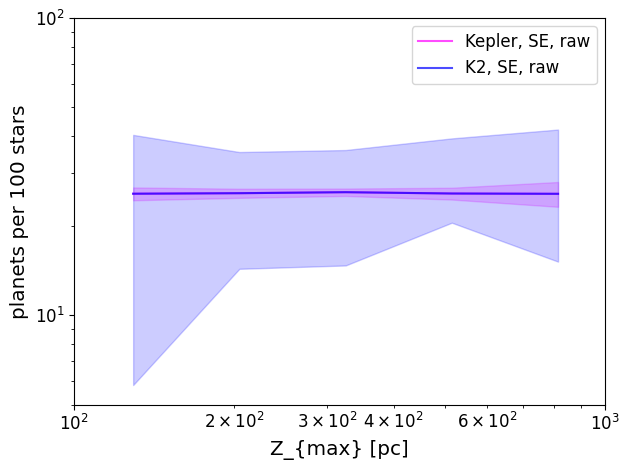

In [57]:
plt.plot(height_bin_midpoints, np.mean(physical_planet_occurrences_SE_kepler, axis=0), label='Kepler, SE, raw', c='magenta', alpha=0.7)
plt.fill_between(height_bin_midpoints, np.mean(physical_planet_occurrences_SE_kepler, axis=0)+np.std(physical_planet_occurrences_SE_kepler, axis=0), np.mean(physical_planet_occurrences_SE_kepler, axis=0)-np.std(physical_planet_occurrences_SE_kepler, axis=0), color='magenta', alpha=0.2)
plt.plot(height_bin_midpoints, np.mean(physical_planet_occurrences_SE_kepler, axis=0), label='K2, SE, raw', c='blue', alpha=0.7)
plt.fill_between(height_bin_midpoints, np.mean(physical_planet_occurrences_SE_k2, axis=0)+np.std(physical_planet_occurrences_SE_k2, axis=0), np.mean(physical_planet_occurrences_SE_k2, axis=0)-np.std(physical_planet_occurrences_SE_k2, axis=0), color='blue', alpha=0.2)

plt.xlim([100, 1000])
plt.ylim([5, 100])
plt.xlabel(r'Z_{max} [pc]')
plt.ylabel('planets per 100 stars')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

Hold on, i need to check something. In Z23, they use the AD test of the CDF, presumably over Zmax. Let's actually try that, instead of binning by 5. Although, there they take the CDF in P, R space, not Zmax space. I wonder if this is fine for us to do

[330.22736518 538.02612825 291.31707622 ... 204.9568013  340.67692278
 690.54253311]


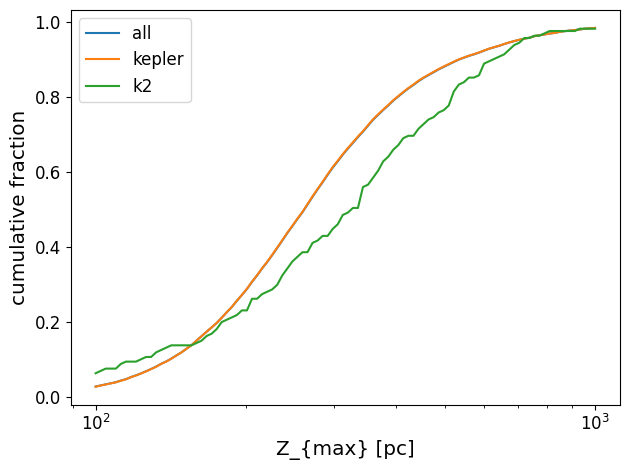

In [ ]:
from scipy.stats import ecdf

all_heights = np.array(kepler_k2_planets_temp['height'])
all_heights = np.asarray(all_heights, dtype=float)
print(all_heights)

kepler_heights = np.array(kepler_planets_temp['height'])
kepler_heights = np.asarray(kepler_heights, dtype=float)

k2_heights = np.array(k2_planets_temp['height'])
k2_heights = np.asarray(k2_heights, dtype=float)

all_res = ecdf(all_heights)
all_cdf_vals = all_res.cdf.evaluate(np.logspace(2,3,100))
kepler_res = ecdf(kepler_heights)
kepler_cdf_vals = kepler_res.cdf.evaluate(np.logspace(2,3,100))
k2_res = ecdf(k2_heights)
k2_cdf_vals = k2_res.cdf.evaluate(np.logspace(2,3,100))

plt.plot(np.logspace(2,3,100), all_cdf_vals, label='all')
plt.plot(np.logspace(2,3,100), kepler_cdf_vals, label='kepler')
plt.plot(np.logspace(2,3,100), k2_cdf_vals, label='k2')

plt.xlabel(r'$Z_{max}$ [pc]')
plt.xscale('log')
plt.ylabel('cumulative fraction')
plt.legend()
plt.tight_layout()
plt.show()

[25.118864315095802, 24.94072598262274, 24.763850974203592, 24.5882303305782, 24.41385515602381, 24.240716617904496, 24.068805946223755, 23.898114433180254, 23.728633432726795, 23.56035436013233, 23.393268691547142, 23.227367963571073, 23.06264377282483, 22.899087775524336, 22.73669168705808, 22.575447281567477, 22.415346391530214, 22.256380907346536, 22.09854277692846, 21.941824005291927, 21.786216654151808, 21.631712841519835, 21.47830474130534, 21.325984582918842, 21.17474465087843, 21.024577284418967, 20.875474877104054, 20.727429876440716, 20.580434783496866, 20.43448215252145, 20.2895645905673, 20.14567475711667, 20.002805363709392, 19.860949173573715, 19.720099001259733, 19.58024771227543, 19.44138822272525, 19.30351349895136, 19.166616557177292, 19.030690463154233, 18.89572833180978, 18.761723326899205, 18.628668660659127, 18.49655759346376, 18.36538343348347, 18.235139536345844, 18.105819304799144, 17.977416188378108, 17.849923683072152, 17.723335330995944, 17.597644720062263,

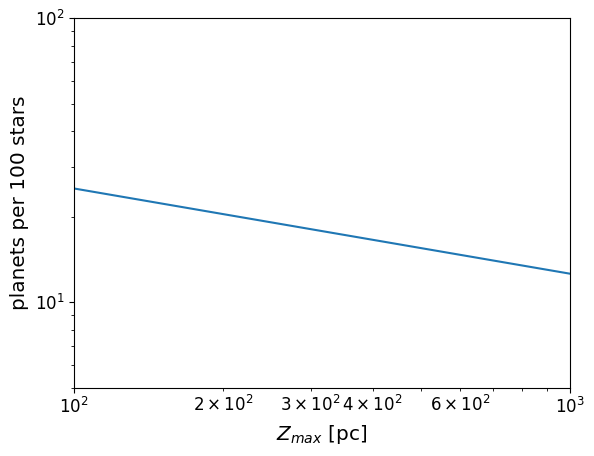

In [117]:
def eqn4_analytic(zmax, teff, kappa, gamma, tau):
    dln = 0.0011
    scaleMax= 1000
    scaleMin = 100
    const = (scaleMax)**(tau+1)/(tau+1) - ((scaleMin)**(tau+1)/(tau+1))

    planet_yield = const * 10**(teff*gamma/1000) * np.power(zmax, tau)
    return 10 * planet_yield

def eqn4_analytic_no_teff(zmax, kappa, tau):
    # dln = 0.0011
    # scaleMax= 1000
    # scaleMin = 100
    # const = (scaleMax)**(tau+1)/(tau+1) - ((scaleMin)**(tau+1)/(tau+1))

    planet_yield = 100 * kappa * np.power(zmax, tau)
    return planet_yield

n_med = []
for i in z_max:
    #dn = np.sum(eqn4_analytic(i, np.linspace(4000, 7500, 100), 1, -0.14, -0.3))
    dn = np.sum(eqn4_analytic_no_teff(i, 1, -0.3))
    n_med.append(dn)

    #dn = np.sum(eqn4_analytic(i, np.linspace(4000, 7500, 100), 1, -0.14, -0.3))

print(n_med)
plt.plot(z_max, n_med)
plt.xlim([100, 1000])
plt.ylim([5, 100])
plt.xlabel(r'$Z_{max}$ [pc]')
plt.ylabel('planets per 100 stars')
plt.xscale('log')
plt.yscale('log')
plt.show()

        

In [ ]:
def model(x, tau, occurrence):

    dln = 0.0011
    scaleMax= 1000
    scaleMin = 100
    const = (scaleMax)**(tau+1)/(tau+1) - ((scaleMin)**(tau+1)/(tau+1))
    planet_yield = occurrence * x**(tau)/const/dln * 100
    
    return planet_yield

def power_model(x, yerr, y=None): # from Zink+23

    tau = numpyro.sample("tau", dist.Uniform(-1., 1.))
    occurrence = numpyro.sample("occurrence", dist.Uniform(0.01, 1.))

    dln = 0.0011
    scaleMax= 1000
    scaleMin = 100
    const = (scaleMax)**(tau+1)/(tau+1) - ((scaleMin)**(tau+1)/(tau+1))
    planet_yield = occurrence * x**(tau)/const/dln * 100
    # print("planet yield: ", planet_yield)
    # print("yerr: ", yerr)
    # print("y: ", y)
    # print("tau: ", tau)
    # print("occurrence: ", occurrence)
    # print("sample model: ", model(z_max, tau, occurrence))
    with numpyro.plate("data", len(x)):
        numpyro.sample("planet_yield", dist.Normal(planet_yield, yerr), obs=y)

def run_model(std, mean, warmup=1000, samples=5000, chains=4):        
	opt_params = run_optim(jax.random.PRNGKey(5), height_bin_midpoints, std, y=mean)

	# sample posteriors for best-fit model to simulated data
	sampler = infer.MCMC(
		infer.NUTS(power_model, dense_mass=True,
			regularize_mass_matrix=False,
			init_strategy=numpyro.infer.init_to_value(values=opt_params)), 
		num_warmup=warmup,
		num_samples=samples,
		num_chains=chains,
		progress_bar=True,
	)

	sampler.run(jax.random.PRNGKey(0), height_bin_midpoints, std, y=mean)
	inf_data = az.from_numpyro(sampler)
	#print(az.summary(inf_data))
	return inf_data


# find MAP solution
init_params = {
    "tau": -0.35,
    "occurrence": 0.3,
}

run_optim = numpyro_ext.optim.optimize(
        power_model, init_strategy=numpyro.infer.init_to_median()
    )
opt_params = run_optim(jax.random.PRNGKey(5), height_bin_midpoints, std_detected_occurrences, y=mean_detected_occurrences)

# sample posteriors for best-fit model to simulated data
sampler = infer.MCMC(
    infer.NUTS(power_model, dense_mass=True,
        regularize_mass_matrix=False,
        init_strategy=numpyro.infer.init_to_value(values=opt_params)), 
    num_warmup=10000,
    num_samples=10000,
    num_chains=4,
    progress_bar=True,
)

sampler.run(jax.random.PRNGKey(0), height_bin_midpoints, std_detected_occurrences, y=mean_detected_occurrences)
inf_data = az.from_numpyro(sampler)
print(az.summary(inf_data))

tau_ours = inf_data.posterior.data_vars['tau'].mean().values
print("tau: ", tau_ours)
tau_std = inf_data.posterior.data_vars['tau'].std().values
print("tau std: ", tau_std)

occurrence_ours = inf_data.posterior.data_vars['occurrence'].mean().values
print("occurrence: ", occurrence_ours)
occurrence_std = inf_data.posterior.data_vars['occurrence'].std().values
print("occurrence std: ", occurrence_std)

NameError: name 'std_detected_occurrences' is not defined

In [123]:
# zink model
# calculate all models so that we can take one-sigma envelope
yield_max = []
yield_min = []
yield_max_se = []
yield_min_se = []
yield_max_sn = []
yield_min_sn = []
models_se = []
models_sn = []
z_max = np.logspace(2, 3.02, 100)
zink_csv = pd.read_csv(path+'data/SupEarths_combine_GaxScale_teff_fresh.csv')
zink_csv_sn = pd.read_csv(path+'data/SubNeptunes_combine_GaxScale_teff_fresh.csv')[['Occurrence','Gamma','Tau']]

# SEs
for i in range(len(zink_csv)):
    row = zink_csv.iloc[i]
    models_se.append(model(z_max, row['Tau'], row['Occurrence']))
zink_csv['model'] = models_se

# SNs
for j in range(len(zink_csv_sn)):
    row = zink_csv_sn.iloc[i]
    models_sn.append(model(z_max, row['Tau'], row['Occurrence']))
zink_csv_sn['model'] = models_sn
sum_model = zink_csv['model'] + zink_csv_sn['model']
for temp_list in zip_longest(*sum_model):
    yield_max.append(np.percentile(temp_list, 84)) # plus one sigma
    yield_min.append(np.percentile(temp_list, 16)) # minus one sigma
for temp_list in zip_longest(*zink_csv['model']):
    yield_max_se.append(np.percentile(temp_list, 84)) # plus one sigma
    yield_min_se.append(np.percentile(temp_list, 16)) # minus one sigma
for temp_list in zip_longest(*zink_csv_sn['model']):
    yield_max_sn.append(np.percentile(temp_list, 84)) # plus one sigma
    yield_min_sn.append(np.percentile(temp_list, 16)) # minus one sigma

In [124]:
zink_csv

,Occurrence,Gamma,Tau,model
0,0.232373,-0.000083,-0.396229,"[42.2926242313213, 41.896936813994124, 41.5049..."
1,0.226011,-0.000131,-0.340879,"[38.023506699444674, 37.717255131161934, 37.41..."
2,0.234405,-0.000177,-0.375463,"[41.42801075856778, 41.06063598296685, 40.6965..."
3,0.237532,-0.000208,-0.266185,"[35.86909425747303, 35.64329912457502, 35.4189..."
4,0.230179,-0.000143,-0.330163,"[38.134169277316424, 37.83664385493863, 37.541..."
...,...,...,...,...
1435,0.232491,-0.000121,-0.256829,"[34.63048891986127, 34.42013030900429, 34.2110..."
1436,0.237647,-0.000073,-0.328614,"[39.28383155947144, 38.978769095525706, 38.676..."
1437,0.231770,-0.000148,-0.291613,"[36.31916482882776, 36.06877162984756, 35.8201..."
1438,0.227933,-0.000176,-0.313942,"[36.89060481891556, 36.616870492567685, 36.345..."


In [125]:
zink_csv_sn

,Occurrence,Gamma,Tau,model
0,0.220900,-0.000217,-0.315981,"[37.72693140679806, 37.4054243831981, 37.08665..."
1,0.208341,-0.000267,-0.525691,"[37.72693140679806, 37.4054243831981, 37.08665..."
2,0.207241,-0.000278,-0.408148,"[37.72693140679806, 37.4054243831981, 37.08665..."
3,0.210568,-0.000228,-0.393514,"[37.72693140679806, 37.4054243831981, 37.08665..."
4,0.202610,-0.000250,-0.346871,"[37.72693140679806, 37.4054243831981, 37.08665..."
...,...,...,...,...
1435,0.219541,-0.000283,-0.431418,"[37.72693140679806, 37.4054243831981, 37.08665..."
1436,0.208654,-0.000293,-0.282149,"[37.72693140679806, 37.4054243831981, 37.08665..."
1437,0.208282,-0.000308,-0.383558,"[37.72693140679806, 37.4054243831981, 37.08665..."
1438,0.204875,-0.000215,-0.223889,"[37.72693140679806, 37.4054243831981, 37.08665..."


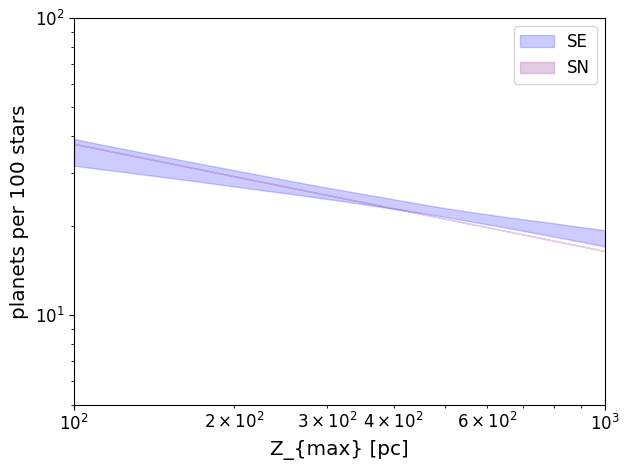

In [118]:
plt.fill_between(z_max, yield_min_se, yield_max_se, alpha=0.2, color='blue', label='SE')
plt.fill_between(z_max, yield_min_sn, yield_max_sn, alpha=0.2, color='purple', label='SN')
plt.xlim([100, 1000])
plt.ylim([5, 100])
plt.xlabel(r'Z_{max} [pc]')
plt.ylabel('planets per 100 stars')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

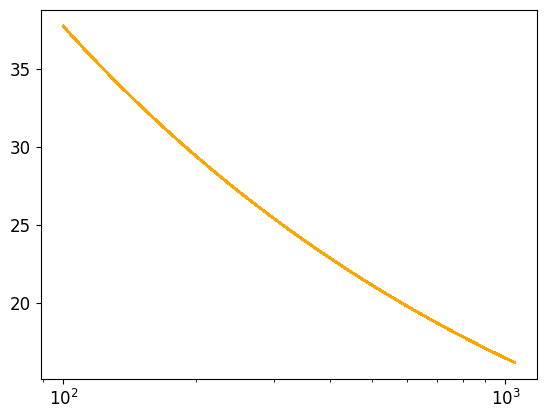

In [95]:
# for m in models_se:
#     plt.plot(z_max, m, c='orange', alpha=0.2)
# plt.xscale('log')
# plt.show()

for m in models_sn:
    plt.plot(z_max, m, c='orange', alpha=0.2)
plt.xscale('log')
plt.show()

In [ ]:
def eqn4(zmax, )

model(z_max, -0.14, occurrence)

100

NameError: name 'zink_kepler' is not defined

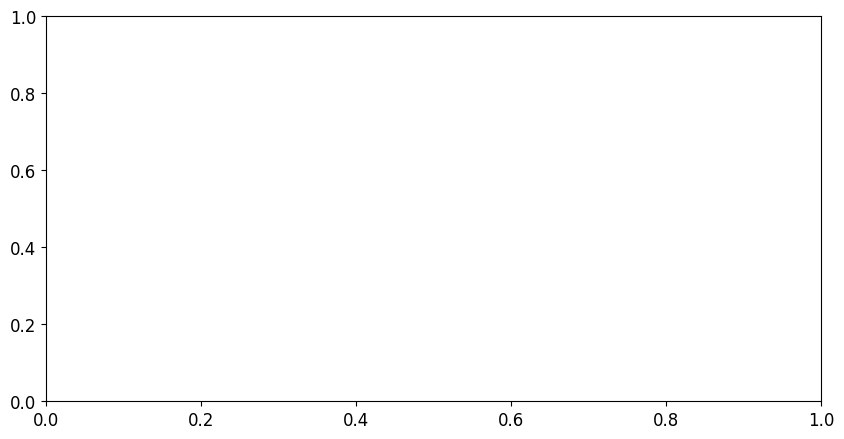

In [84]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

# zink+2023
ax1.errorbar(x=height_bin_midpoints, y=zink_kepler['occurrence'], yerr=(zink_kepler['occurrence_err1'], zink_kepler['occurrence_err2']), fmt='o', color='red', alpha=0.5, capsize=3, elinewidth=1, markeredgewidth=1, label='Zink+ 2023 Kepler data')
ax1.fill_between(z_max, yield_max, yield_min, color='red', alpha=0.3, label='Zink+ 2023 posteriors') #03acb1
